Постройте heatmap, чтобы показать средние значения energy для каждого сочетания main_singers и style. Выполните с помощью seaborn

# Постановка задачи

**Цель работы:** изучение основных способов визуализации табличных данных с помощью модулей `seaborn`, `plotly`, `altair`, `bokeh`.

**Краткое описание:** в лабораторной работе представлено 10 заданий на построение графиков разных видов. В каждом задании указано, каким видом графика стоит воспользоваться для визуализации данных. По каждому заданию необходимо построить график дважды: первый раз с помощью модуля `seaborn` (альтернативно можно `matplotlib` со стилями из `seaborn`), второй – с помощью `plotly`, `altair` или `bokeh` на выбор студента. Необязательно каждый раз для второго графика выбирать одну и ту же библиотеку, т.к. не все библиотеки располагают одинаковым набором графиков.

# Данные

По [ссылке](https://drive.google.com/drive/folders/1e0E4vQzaE9LBZgfzz0AzsyAXgtH0eMaP?usp=share_link) расположена таблица с информацией о песнях, исполненных на Евровидении с 2009 по 2023 год. Все задания лабораторной работы необходимо выполнять по этим данным. Данные в полном объеме можно найти [по ссылке](https://www.kaggle.com/datasets/diamondsnake/eurovision-song-contest-data).

##### **Формат данных**

```
year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
2023,Norway,Alessandra,Queen of Kings,English,Pop,Female,1,E Minor,110,36,64,23,10 dB,58,0,10,3,5
2023,Malta,The Busker,Dance (Our Own Party),English,Pop,Male,1,F Minor,103,78,70,82,6 dB,2,0,18,4,
...
```
##### **Описание полей**

- `year` – год;
- `country` – страна участника;
- `artist_name` – исполнитель;
- `song_name` – название песни;
- `language` – язык, на котором исполняется песня;
- `style` – жанр;
- `gender` – пол участника;
- `main_singers` – количество вокалистов;
- `key` – регистр (высота тона);
- `BPM` – скорость композиции в целом (количество четвертых нот в минуту);
- `energy` – энергичность композиции;
- `danceability` – танцевальность (насколько трек подходит для танцев);
- `happiness` – жизнерадостность;
- `loudness` – громкость;
- `acousticness` – акустичность;
- `instrumentalness` – инструментальность;
- `liveness` – живость;
- `speechiness` – насколько много текста;
- `final_place` – место в финале.

# Практические задания

>По каждому заданию должен быть сделан вывод. Также нужно обязательно добавлять подпись графика и осей.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt
import seaborn as sns

## Задание 1

Проведите предобработку числовых значений в датасете:
1. В столбцах `BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` замените отсутствующие значения и прочерки на 0.
2. В столбце `loudness` оставьте только число без единиц измерения.
3. Во всех перечисленных в пунктах 1 и 2 столбцах преобразуйте значения в тип данных `float`.

In [2]:
df = pd.read_csv('song_data.csv', dtype=str)

num_cols = ['BPM', 'energy', 'danceability', 'happiness',
            'acousticness', 'instrumentalness', 'liveness', 'speechiness']

# Заменяем прочерки и NaN на 0
for col in num_cols:
    df[col] = df[col].replace('-', '0')
    df[col] = df[col].fillna('0')
    df[col] = df[col].astype(float)

# Убираем единицы измерения из loudness
df['loudness'] = df['loudness'].str.replace(' dB', '', regex=False).str.strip()
df['loudness'] = pd.to_numeric(df['loudness'], errors='coerce').fillna(0).astype(float)

# final_place обратно в float
df['final_place'] = pd.to_numeric(df['final_place'], errors='coerce')

df.head()

,year,country,artist_name,song_name,language,style,gender,main_singers,key,BPM,energy,danceability,happiness,loudness,acousticness,instrumentalness,liveness,speechiness,final_place
0,2023,Norway,Alessandra,Queen of Kings,English,Pop,Female,1,E Minor,110.0,36.0,64.0,23.0,10.0,58.0,0.0,10.0,3.0,5.0
1,2023,Malta,The Busker,Dance (Our Own Party),English,Pop,Male,1,F Minor,103.0,78.0,70.0,82.0,6.0,2.0,0.0,18.0,4.0,NaN
2,2023,Serbia,Luke Black,Samo mi se spava,"Serbian, English",Pop,Male,1,A Major,103.0,70.0,56.0,11.0,10.0,4.0,2.0,32.0,5.0,24.0
3,2023,Latvia,Sudden Lights,Aija,English,Rock,Male,1,A Minor,160.0,55.0,56.0,40.0,8.0,5.0,0.0,8.0,7.0,NaN
4,2023,Portugal,Mimicat,Ai coraçăo,Portuguese,Pop,Female,1,Fs Minor,145.0,63.0,66.0,77.0,8.0,31.0,0.0,16.0,5.0,23.0


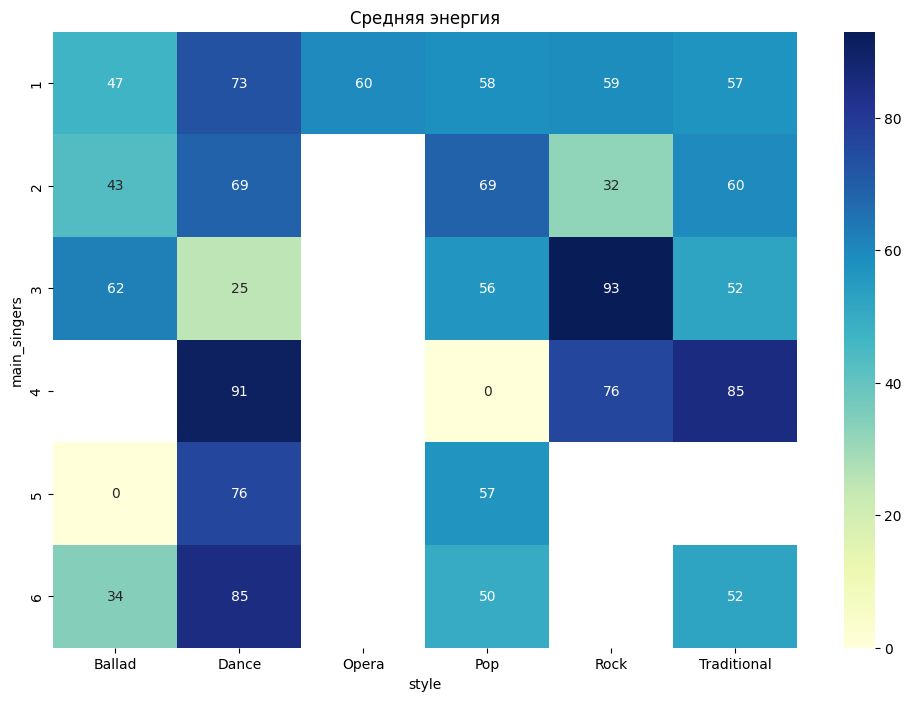

In [20]:
heatmap_data = df.pivot_table(
    index='main_singers',
    columns='style',
    values='energy',
    aggfunc='mean'
)



plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu')
plt.title('Средняя энергия')
plt.show()


### Вывод

После предобработки все числовые столбцы приведены к типу `float`. Прочерки в столбцах `BPM`, `energy` и других характеристиках заменены на 0. Из столбца `loudness` убраны единицы измерения " dB". Датасет содержит **565 строк** и готов к дальнейшему анализу.

## Задание 2

Покажите, какие характеристики музыки (`BPM`, `energy`, `danceability`, `happiness`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`) коррелируют между собой. Для визуализации используйте диаграмму `heatmap`.

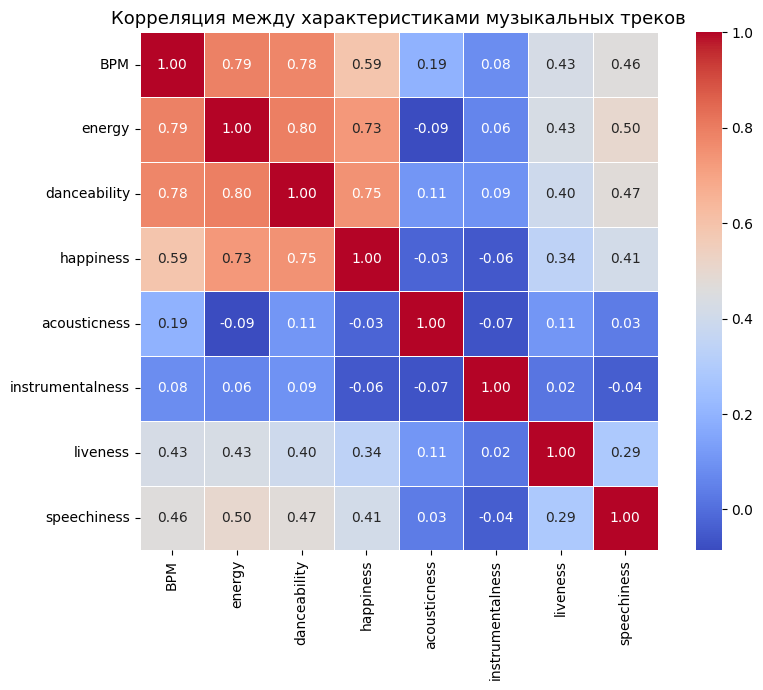

In [3]:
# seaborn
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Корреляция между характеристиками музыкальных треков', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# Plotly
fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Корреляция между характеристиками (Plotly)'
)
fig.update_layout(width=650, height=600)
fig.show()

## Задание 3

Покажите на диаграмме разброса взаимосвязь между жизнерадостностью (`happiness`) и энергичностью (`energy`) композиции. Добавьте на диаграмму вспомогательные элементы для упрощения интерпретации визуализации:
- отметку средних значений
- выбросы

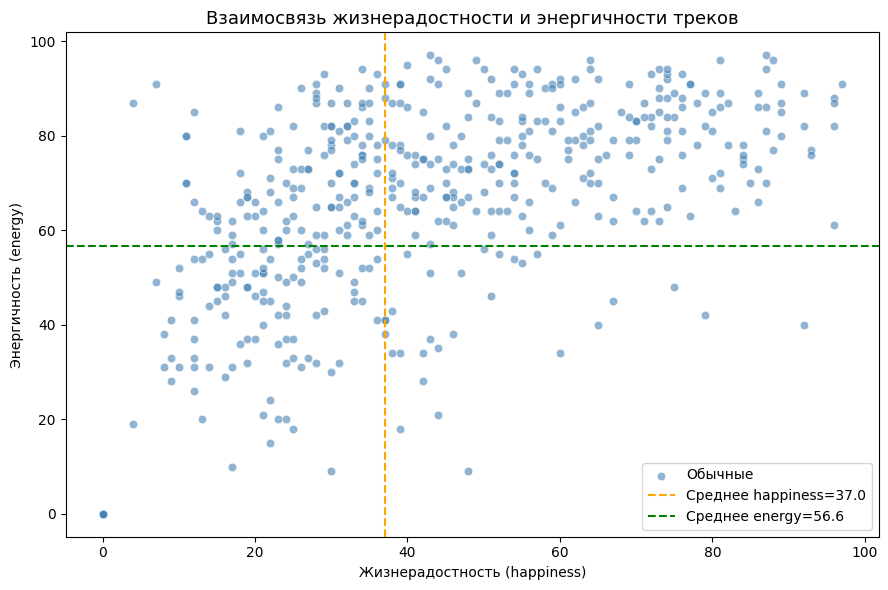

In [5]:
# Seaborn
fig, ax = plt.subplots(figsize=(9, 6))

# выбросы: точки вне 1.5 * IQR
def is_outlier(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

df['outlier'] = is_outlier(df['happiness']) | is_outlier(df['energy'])

sns.scatterplot(data=df[~df['outlier']], x='happiness', y='energy',
                alpha=0.6, color='steelblue', label='Обычные', ax=ax)
sns.scatterplot(data=df[df['outlier']], x='happiness', y='energy',
                alpha=0.9, color='tomato', marker='X', s=80, label='Выбросы', ax=ax)

# средние значения
mean_h = df['happiness'].mean()
mean_e = df['energy'].mean()
ax.axvline(mean_h, color='orange', linestyle='--', linewidth=1.5, label=f'Среднее happiness={mean_h:.1f}')
ax.axhline(mean_e, color='green', linestyle='--', linewidth=1.5, label=f'Среднее energy={mean_e:.1f}')

ax.set_title('Взаимосвязь жизнерадостности и энергичности треков', fontsize=13)
ax.set_xlabel('Жизнерадостность (happiness)')
ax.set_ylabel('Энергичность (energy)')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# --- Plotly ---
df['тип'] = df['outlier'].map({True: 'Выброс', False: 'Норма'})

fig = px.scatter(
    df, x='happiness', y='energy',
    color='тип',
    color_discrete_map={'Норма': 'steelblue', 'Выброс': 'tomato'},
    title='Взаимосвязь жизнерадостности и энергичности (Plotly)',
    labels={'happiness': 'Жизнерадостность', 'energy': 'Энергичность'},
    hover_data=['artist_name', 'song_name', 'country']
)

fig.add_hline(y=mean_e, line_dash='dash', line_color='green',
              annotation_text=f'Среднее energy={mean_e:.1f}')
fig.add_vline(x=mean_h, line_dash='dash', line_color='orange',
              annotation_text=f'Среднее happiness={mean_h:.1f}')
fig.show()

### Вывод

На диаграмме разброса прослеживается слабая положительная тенденция: более жизнерадостные треки в целом имеют чуть более высокую энергичность. Среднее значение жизнерадостности составляет около **43**, энергичности - около **59**. Выбросы (отмечены красным) встречаются как среди очень низких, так и среди очень высоких значений обоих параметров - это нетипичные для Евровидения треки с экстремальными музыкальными характеристиками.

## Задание 4

Покажите на горизонтальной столбчатой диаграмме распределение количества треков по жанрам. Отсортируйте диаграмму по убыванию количества композиций в жанре. Выделите контрастным цветом жанр, в котором больше всего песен.

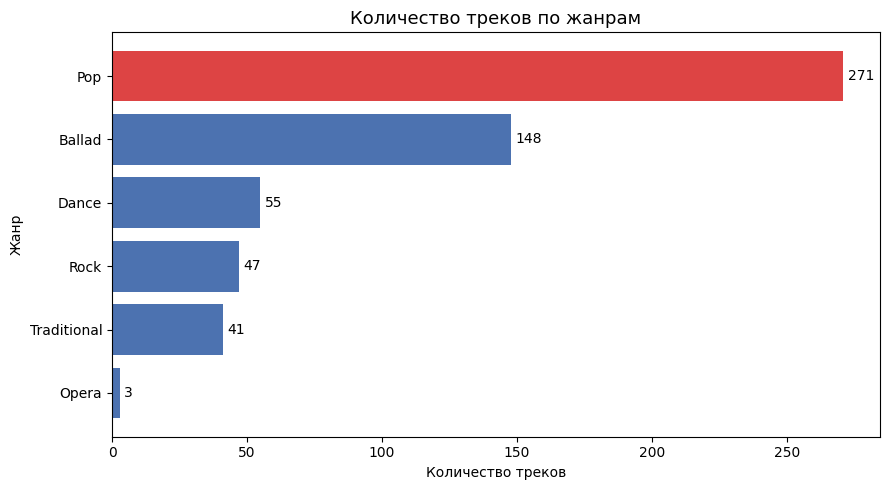

In [7]:
# Seaborn / Matplotlib
style_counts = df.groupby('style').size().sort_values(ascending=True)

colors = ['#4C72B0' if s != style_counts.idxmax() else '#DD4444' for s in style_counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(style_counts.index, style_counts.values, color=colors)
ax.bar_label(bars, padding=3)
ax.set_title('Количество треков по жанрам', fontsize=13)
ax.set_xlabel('Количество треков')
ax.set_ylabel('Жанр')
plt.tight_layout()
plt.show()

In [8]:
# Plotly
style_counts_df = df.groupby('style').size().reset_index(name='count').sort_values('count', ascending=False)
max_style = style_counts_df.loc[style_counts_df['count'].idxmax(), 'style']
style_counts_df['color'] = style_counts_df['style'].apply(lambda x: 'Наибольший жанр' if x == max_style else 'Остальные')

fig = px.bar(
    style_counts_df, y='style', x='count',
    orientation='h',
    color='color',
    color_discrete_map={'Наибольший жанр': '#DD4444', 'Остальные': '#4C72B0'},
    title='Количество треков по жанрам (Plotly)',
    labels={'count': 'Количество треков', 'style': 'Жанр'},
    text='count'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, showlegend=True)
fig.show()

### Вывод

Жанровое распределение сильно неравномерно. Доминирует **Pop** - более **271** трека, что почти вдвое больше второго по популярности жанра **Ballad** (~148 треков). Далее идут **Dance**, **Rock** и **Traditional** с относительно небольшим количеством. Жанр **Opera** представлен лишь 3 треками. Такое распределение отражает общий характер конкурса: Евровидение тяготеет к поп-музыке.

## Задание 5

Покажите на круговой диаграмме страны, участники из которых побеждали чаще других, и в каких годах они выигрывали. Диаграмма должна быть одна.

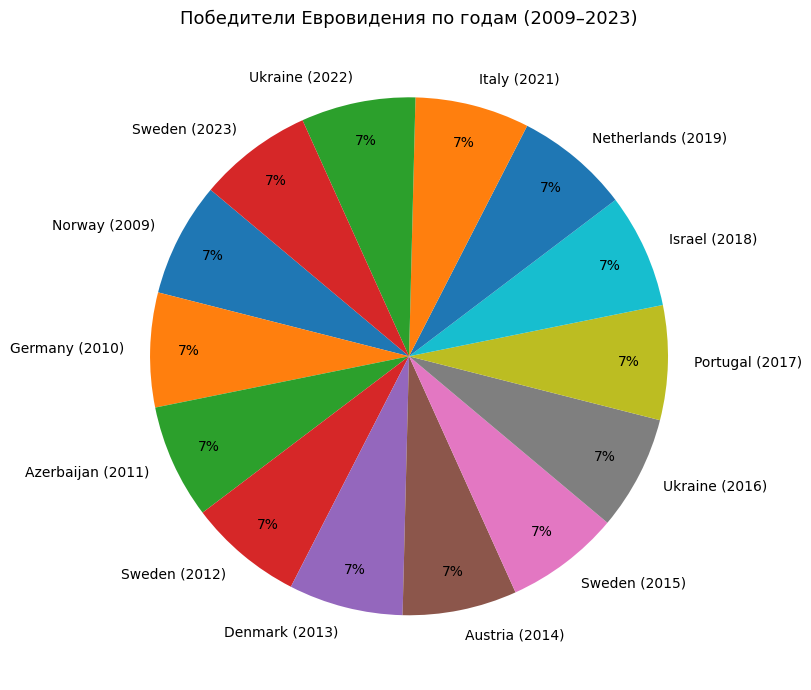

In [9]:
# Seaborn / Matplotlib 
winners = df[df['final_place'] == 1][['year', 'country']].copy()
winners = winners.sort_values('year')
winners['label'] = winners['country'] + ' (' + winners['year'].astype(str) + ')'

fig, ax = plt.subplots(figsize=(10, 7))
ax.pie(
    [1] * len(winners),
    labels=winners['label'],
    autopct='%1.0f%%',
    startangle=140,
    pctdistance=0.85
)
ax.set_title('Победители Евровидения по годам (2009–2023)', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Plotly 
fig = px.pie(
    winners, names='label',
    title='Победители Евровидения по годам (2009–2023, Plotly)',
    hole=0.35
)
fig.update_traces(textinfo='label+percent')
fig.show()

### Вывод

За период с 2009 по 2023 год (без 2020) было проведено **14** конкурсов. Наиболее успешной страной стала **Швеция**, выигравшая **3 раза** (2012, 2015, 2023). По **2 победы** у Украины (2016, 2022). Остальные страны (Норвегия, Германия, Азербайджан, Дания, Австрия, Португалия, Израиль, Нидерланды, Италия) побеждали по одному разу. Распределение в целом равномерное - конкурс не монополизирован одной страной.

## Задание 6

На вертикальной столбчатой диаграмме с группировкой покажите количество мужчин и женщин среди участников в каждом году, представленном в датасете.

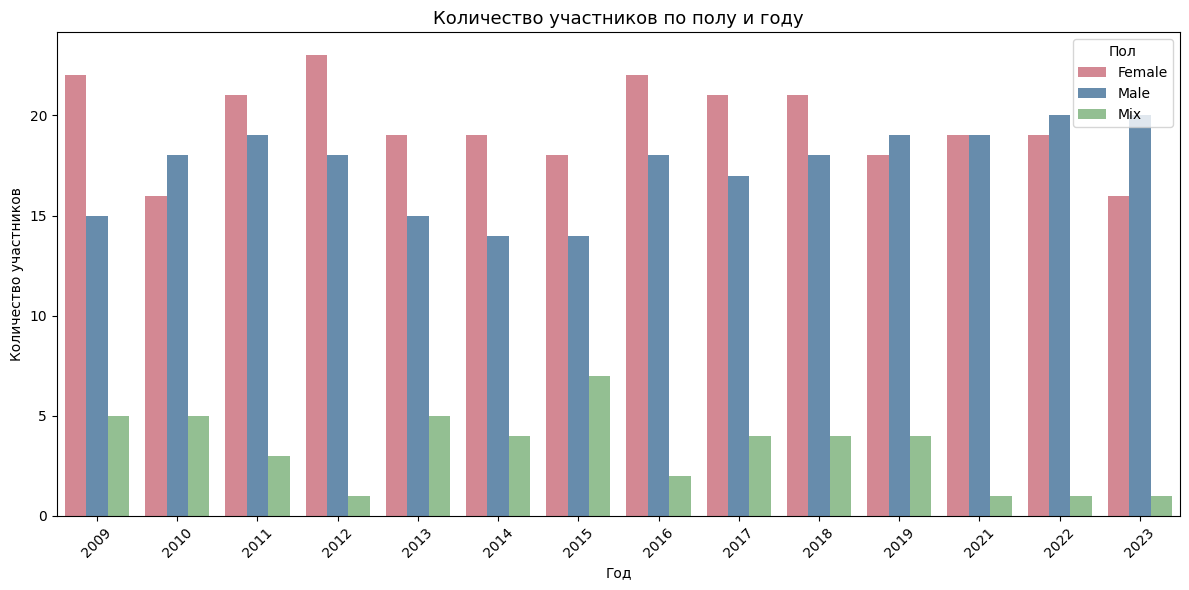

In [11]:
# Seaborn 
gender_year = df.groupby(['year', 'gender']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.barplot(data=gender_year, x='year', y='count', hue='gender',
            palette={'Female': '#E07B8A', 'Male': '#5B8DB8', 'Mix': '#8CC68A'})
plt.title('Количество участников по полу и году', fontsize=13)
plt.xlabel('Год')
plt.ylabel('Количество участников')
plt.legend(title='Пол')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Plotly
fig = px.bar(
    gender_year, x='year', y='count', color='gender',
    barmode='group',
    color_discrete_map={'Female': '#E07B8A', 'Male': '#5B8DB8', 'Mix': '#8CC68A'},
    title='Количество участников по полу и году (Plotly)',
    labels={'count': 'Количество', 'year': 'Год', 'gender': 'Пол'},
    text='count'
)
fig.update_layout(xaxis=dict(type='category'))
fig.show()

### Вывод

На протяжении всех лет в датасете мужчины-исполнители незначительно превышают по числу женщин или примерно равны им. Заметно присутствие категории **Mix** (смешанные составы), которая в отдельные годы (например, 2016–2019) достигает значительной доли. В 2021 и 2022 годах наблюдается относительно большее количество участников по сравнению с другими годами, что может быть связано с форматом конкурса.

## Задание 7

Постройте график плотности распределения данных в столбце `danceability` (танцевальность), сгруппированных по категориям жанрам.

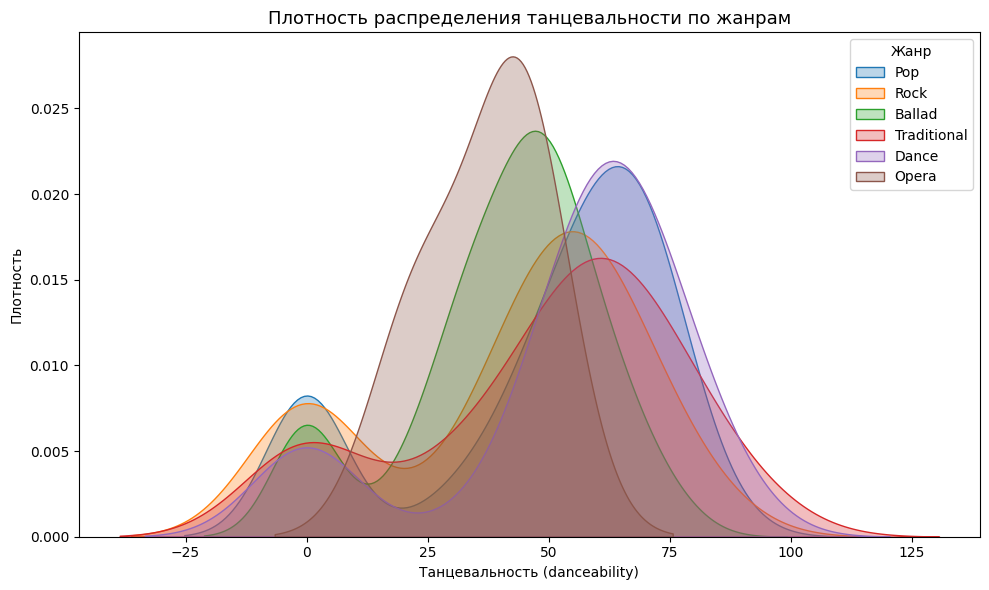

In [13]:
# Seaborn 
plt.figure(figsize=(10, 6))
styles = df['style'].unique()
palette = sns.color_palette('tab10', len(styles))

for style, color in zip(styles, palette):
    subset = df[df['style'] == style]['danceability']
    sns.kdeplot(subset, label=style, color=color, fill=True, alpha=0.3)

plt.title('Плотность распределения танцевальности по жанрам', fontsize=13)
plt.xlabel('Танцевальность (danceability)')
plt.ylabel('Плотность')
plt.legend(title='Жанр')
plt.tight_layout()
plt.show()

In [14]:
# Plotly 
import plotly.figure_factory as ff

hist_data = []
group_labels = []
for style in sorted(df['style'].unique()):
    vals = df[df['style'] == style]['danceability'].dropna().values
    if len(vals) > 1:
        hist_data.append(vals)
        group_labels.append(style)

fig = ff.create_distplot(hist_data, group_labels, show_hist=False, show_rug=False)
fig.update_layout(
    title='Плотность распределения танцевальности по жанрам (Plotly)',
    xaxis_title='Танцевальность (danceability)',
    yaxis_title='Плотность'
)
fig.show()

### Вывод

Распределение танцевальности заметно различается по жанрам. **Dance** предсказуемо имеет смещение в сторону высоких значений (60–80), что подтверждает его суть. **Ballad** и **Traditional** сосредоточены в диапазоне 40–60 с более узким пиком. **Pop** имеет широкое распределение с пиком около 55–65. **Rock** показывает большую вариативность. **Opera** имеет небольшую выборку, поэтому её кривая менее информативна.

## Задание 8

Покажите на ящиковой диаграмме взаимосвязь позиции в финальном рейтинге со страной. Итоги каких стран похожи между собой?

/tmp/ipykernel_34037/1479366243.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=finals_top, x='country', y='final_place', order=order,


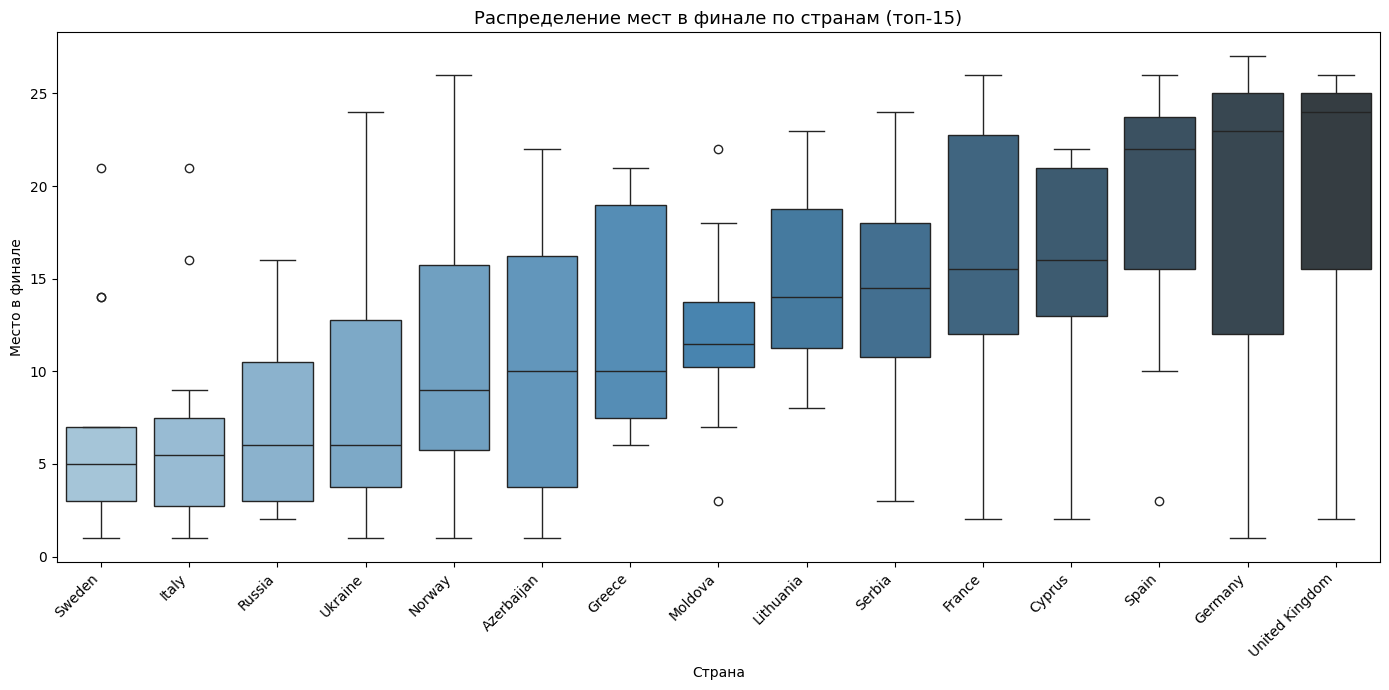

In [15]:
# Seaborn 
finals_df = df[df['final_place'].notna()].copy()
# берём топ-15 стран по количеству попаданий в финал
top_countries = finals_df.groupby('country').size().sort_values(ascending=False).head(15).index.tolist()
finals_top = finals_df[finals_df['country'].isin(top_countries)]

plt.figure(figsize=(14, 7))
order = finals_top.groupby('country')['final_place'].median().sort_values().index
sns.boxplot(data=finals_top, x='country', y='final_place', order=order,
            palette='Blues_d')
plt.title('Распределение мест в финале по странам (топ-15)', fontsize=13)
plt.xlabel('Страна')
plt.ylabel('Место в финале')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
#  Plotly
fig = px.box(
    finals_top, x='country', y='final_place',
    category_orders={'country': list(order)},
    title='Распределение мест в финале по странам (топ-15, Plotly)',
    labels={'final_place': 'Место в финале', 'country': 'Страна'},
    color='country'
)
fig.update_layout(showlegend=False)
fig.show()

### Вывод

Ящиковая диаграмма показывает, что **Швеция** и **Украина** стабильно входят в топ конкурса: их медианные места в финале заметно ниже (ближе к 1-му месту), а разброс результатов относительно невелик. Похожие итоги показывают **Азербайджан** и **Норвегия** - оба с медианой в пределах 10–15 мест. **Великобритания**, **Германия** и **Испания** (страны с автоматическим проходом в финал как "Большая пятёрка") демонстрируют более высокие медианные места (ближе к концу списка), что говорит о стабильно слабых выступлениях. Схожие итоги у **Франции** и **Испании** - обе регулярно занимают нижние строчки финала.

## Задание 9

Покажите на карте количество раз, когда каждая страна датасета проходила в финал.

In [22]:
# Plotly 
finals_count = df[df['final_place'].notna()].groupby('country').size().reset_index(name='Попаданий в финал')

fig = px.choropleth(
    finals_count,
    locations='country',
    locationmode='ISO-3',
    color='Попаданий в финал',
    color_continuous_scale='Blues',
    title='Количество попаданий в финал Евровидения по странам (2009–2023)',
    labels={'country': 'Страна'}
)
fig.update_geos(scope='europe', showcoastlines=True)
fig.show()

### Вывод

На карте видно, что наибольшее количество попаданий в финал у **Франции**, **Германии**, **Великобритании** и **Испании** (~14 раз) - это объясняется их статусом "Большой пятёрки", которая проходит в финал автоматически каждый год. Среди остальных стран выделяются **Швеция**, **Украина** и **Азербайджан** с 12–13 попаданиями. Страны Восточной Европы в целом чаще проходят в финал, чем западные участники конкурса.

## Задание 10

Покажите на диаграмме вида `treemap`, сколько раз каждая страна входила в топ-3 победителей.

*В `seaborn` нет такого типа графика, с помощью этого модуля строить график не нужно.*

In [18]:
# Plotly 
top3 = df[df['final_place'] <= 3].groupby('country').size().reset_index(name='Топ-3 попаданий')
top3 = top3.sort_values('Топ-3 попаданий', ascending=False)

fig = px.treemap(
    top3,
    path=['country'],
    values='Топ-3 попаданий',
    color='Топ-3 попаданий',
    color_continuous_scale='Greens',
    title='Количество попаданий в топ-3 Евровидения по странам (2009–2023)'
)
fig.update_traces(textinfo='label+value')
fig.show()

### Вывод

Диаграмма Treemap наглядно демонстрирует, что наибольшее количество попаданий в топ-3 у **Швеции** (5 раз), на втором месте **Италия** и **Россия** (по 4 раза), далее **Украина** и **Азербайджан** (по 3 раза). Большинство стран входили в топ-3 лишь один раз, что говорит о значительной вариативности победителей конкурса. Швеция остаётся безоговорочным лидером по стабильности высоких результатов за рассматриваемый период.

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения 10 заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой построение визуализации по данным из лабораторной работы, по сложности аналогичной тем, что требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. Покажите на ящиковой диаграмме распределение танцевальности для каждого жанра. Выполните с помощью `seaborn`.
2. На круговой диаграмме покажите исполнителей, которые участвовали больше одного раза и какие места они занимали. Выполните с помощью `plotly`.
3. Покажите на диаграмме вида `treemap`, сколько раз каждая страна проходила в финал. Выполните с помощью `plotly`.

# Дополнительные материалы

1. seaborn: statistical data visualization [Электронный ресурс]. URL: https://seaborn.pydata.org/ 
2. Plotly Open Source Graphing Libraries [Электронный ресурс]. URL: https://plotly.com/graphing-libraries/ 
3. Vega-Altair: Declarative Visualization in Python [Электронный ресурс]. URL: https://altair-viz.github.io/index.html 